In [153]:
#クレジットカード会員について、A審査の申請をした後半年以内にB審査の申請もするかどうかの予測
#（A審査申請の段階で、申請内容から直近でB審査の申請をしてくるかどうかの予測）

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error

pd.options.display.max_columns = None

In [114]:
#データの読み込み
#個人情報保護のため、カテゴリカルデータ含む諸データは事前に意味を持たない数値に変換済み
dataset=pd.read_csv("oaikoudata2.csv")

In [115]:
#ある一定期間内にA審査の申請をしたカード会員の情報
#「申請有無」は、A審査の申請後半年以内にB審査の申請をしたか否か（1:申請有,2:申請無）
dataset.head()

,No,性別,年齢,住居状況区分,家族状況区分,家族人数区分,家族同居区分,年収区分,勤務形態区分,申込経路,申請理由,審査結果,引上率,申請有無
0,1,2,20代,5,2,1,2,2,2,3,1,4,1.00,0
1,2,1,30代,5,2,1,1,2,2,3,5,4,1.00,0
2,3,1,50代,1,1,4,1,9,2,3,0,1,1.50,0
3,4,2,50代,1,2,1,2,4,2,3,18,1,1.26,0
4,5,1,50代,3,1,2,2,4,2,3,10,1,1.63,0


In [116]:
dataset.shape

(26200, 14)

In [117]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26200 entries, 0 to 26199
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      26200 non-null  int64  
 1   性別      26200 non-null  int64  
 2   年齢      26200 non-null  object 
 3   住居状況区分  26200 non-null  int64  
 4   家族状況区分  26200 non-null  int64  
 5   家族人数区分  26200 non-null  int64  
 6   家族同居区分  26200 non-null  int64  
 7   年収区分    26200 non-null  int64  
 8   勤務形態区分  26200 non-null  int64  
 9   申込経路    26200 non-null  int64  
 10  申請理由    26200 non-null  int64  
 11  審査結果    26200 non-null  int64  
 12  引上率     26200 non-null  float64
 13  申請有無    26200 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 2.8+ MB


In [118]:
dataset.index.values

array([    0,     1,     2, ..., 26197, 26198, 26199])

In [119]:
dataset.columns.values

array(['No', '性別', '年齢', '住居状況区分', '家族状況区分', '家族人数区分', '家族同居区分', '年収区分',
       '勤務形態区分', '申込経路', '申請理由', '審査結果', '引上率', '申請有無'], dtype=object)

In [120]:
dataset.describe()

,No,性別,住居状況区分,家族状況区分,家族人数区分,家族同居区分,年収区分,勤務形態区分,申込経路,申請理由,審査結果,引上率,申請有無
count,26200.000000,26200.000000,26200.000000,26200.000000,26200.000000,26200.000000,26200.000000,26200.000000,26200.000000,26200.000000,26200.000000,26200.000000,26200.000000
mean,14231.280954,1.535038,2.874160,1.489695,2.451489,1.200878,2.660878,3.631870,2.566718,4.719695,1.748664,1.883169,0.147023
std,8113.179595,0.498780,1.937929,0.499903,1.135406,0.400665,2.357184,2.727761,0.495538,4.734258,1.294846,1.258426,0.354136
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,0.000000,1.000000,1.000000,0.000000
25%,7249.750000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.100000,0.000000
50%,14275.500000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,3.000000,3.000000,1.000000,1.500000,0.000000
75%,21226.250000,2.000000,5.000000,2.000000,4.000000,1.000000,4.000000,5.000000,3.000000,8.000000,2.000000,2.250000,0.000000
max,28269.000000,2.000000,7.000000,2.000000,4.000000,2.000000,9.000000,13.000000,3.000000,18.000000,6.000000,31.000000,1.000000


In [122]:
#分析に使用する列のみ抜き出しリネーム
dataset2=dataset[["性別","年齢","年収区分","申請理由","審査結果","引上率","申請有無"]]
dataset2=dataset2.rename(columns={"性別":"sex","年齢":"age","年収区分":"income","申請理由":"reason"\
                                ,"審査結果":"result","引上率":"ration","申請有無":"application"})

In [ ]:
#"勤務形態区分":"work"

In [123]:
dataset2.head()

,sex,age,income,reason,result,ration,application
0,2,20代,2,1,4,1.00,0
1,1,30代,2,5,4,1.00,0
2,1,50代,9,0,1,1.50,0
3,2,50代,4,18,1,1.26,0
4,1,50代,4,10,1,1.63,0


In [131]:
dataset3=pd.get_dummies(data=dataset2,columns=["reason","result"])
dataset3.head()

,sex,age,income,ration,application,reason_0,reason_1,reason_2,reason_3,reason_4,reason_5,reason_6,reason_7,reason_8,reason_9,reason_10,reason_11,reason_12,reason_13,reason_14,reason_15,reason_16,reason_17,reason_18,result_1,result_2,result_4,result_6
0,2,20代,2,1.00,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,30代,2,1.00,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,1,50代,9,1.50,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,2,50代,4,1.26,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False
4,1,50代,4,1.63,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False


In [132]:
dataset3=dataset3.replace("10代","15").replace("20代","25").replace("30代","35").replace("40代","45").replace("50代","55")\
    .replace("60代","65").replace("70代","75").replace("80代","85").replace("90代","95")

In [101]:
#from sklearn.preprocessing import MinMaxScaler
#sc=MinMaxScaler()
#dataset4=sc.fit_transform(dataset3)
#dataset4

In [102]:
#dataset4=pd.DataFrame(data=dataset4,columns=dataset3.columns.values) 

In [134]:
dataset3.head()

,sex,age,income,ration,application,reason_0,reason_1,reason_2,reason_3,reason_4,reason_5,reason_6,reason_7,reason_8,reason_9,reason_10,reason_11,reason_12,reason_13,reason_14,reason_15,reason_16,reason_17,reason_18,result_1,result_2,result_4,result_6
0,2,25,2,1.00,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,35,2,1.00,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,1,55,9,1.50,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,2,55,4,1.26,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False
4,1,55,4,1.63,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False


In [138]:
Y=np.array(dataset3["application"])
X=np.array(dataset3.drop(columns="application"))

In [139]:
print("Y=",Y.shape,",X=",X.shape)

Y= (26200,) ,X= (26200, 27)


In [140]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=0)
X_train,X_valid,Y_train,Y_valid=train_test_split(X_train,Y_train,test_size=0.3,random_state=0)

In [141]:
print("Y_train=",Y_train.shape,",X_train=",X_train.shape)
print("Y_valid=",Y_valid.shape,",X_valid=",X_valid.shape)
print("Y_test=",Y_test.shape,",X_test=",X_test.shape)

Y_train= (12838,) ,X_train= (12838, 27)
Y_valid= (5502,) ,X_valid= (5502, 27)
Y_test= (7860,) ,X_test= (7860, 27)


In [147]:
model=tf.keras.Sequential([
    tf.keras.Input(shape=(27,)),
    tf.keras.layers.Dense(32,activation="relu"),
    tf.keras.layers.Dense(32,activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dense(1,activation="sigmoid")
])
model.compile(optimizer="rmsprop",loss="binary_crossentropy",metrics=["accuracy"])

In [150]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 32)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

In [152]:
log=model.fit(X_train,Y_train,epochs=50,batch_size=64,verbose=True,
              callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss",
                                                          min_delta=0,patience=10,
                                                          verbose=1)],
            validation_data=(X_valid,Y_valid))

ValueError: Invalid dtype: object

Text(0, 0.5, 'crossentropy')

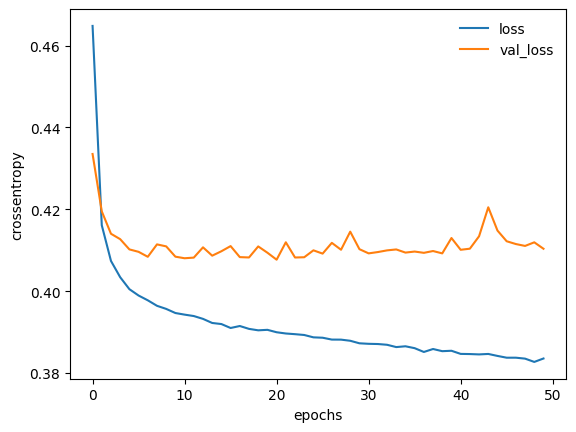

In [111]:
plt.plot(log.history["loss"],label="loss")
plt.plot(log.history["val_loss"],label="val_loss")
plt.legend(frameon=False)
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [ ]:
#memo
#モデル結果が悪い場合、説明変数を減らすことを検討